# Notebook 04: Crossing Strategy Optimization

## Problem Formulation

NFDS naturally drives allele frequencies toward equilibrium (equal frequency), but in small or bottlenecked populations like *Lepidium papilliferum*, this process can be slow. Strategic crossing can **accelerate** what nature already does — not replace it.

Given a population with skewed allele frequencies, we want to find the **optimal crossing strategy** that accelerates convergence toward NFDS equilibrium (equal allele frequency) by prioritizing crosses that boost rare alleles.

### Optimization setup
- **Decision variables**: A weight vector `w` over all compatible crosses. `w[i]` = relative effort allocated to cross `i`.
- **Fitness function**: Negative distance from NFDS equilibrium after applying the crossing plan. We want to **minimize** the distance (maximize fitness).
- **Constraints**: Only SI-compatible crosses are allowed. Weights must be non-negative and sum to 1.

### Strategies compared
1. **Random mating**: Equal weight to all compatible crosses (baseline — lets NFDS work unassisted)
2. **Greedy**: Prioritize crosses that increase the frequency of the rarest alleles
3. **Optimized**: Use `scipy.optimize` to find the weight vector minimizing distance from NFDS equilibrium

In [1]:
import sys
import itertools
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

sns.set_style("whitegrid")

# Import all shared utilities
sys.path.insert(0, "../src")
from polyploid_utils import (
    canonical, allele_frequencies, form_gametes, is_compatible,
    cross, crossing_compatibility, sample_offspring, simulate_generation,
    distance_from_equilibrium, enumerate_compatible_crosses,
    compute_greedy_weights, compute_optimal_weights,
    identify_rare_alleles, get_mandatory_rare_crosses, select_elites,
)

print("All utilities loaded from polyploid_utils (with allele preservation).")

All utilities loaded from polyploid_utils (with allele preservation).


In [2]:
# Same skewed population used throughout the project: 20 individuals, 8 S-alleles.
# S1/S2 overrepresented, S7/S8 rare — a realistic bottlenecked population.
allele_pool = list(range(1, 9))

population = [
    (1, 1, 2, 3),
    (1, 2, 2, 4),
    (1, 1, 3, 5),
    (2, 2, 3, 4),
    (1, 2, 5, 6),
    (1, 3, 4, 5),
    (2, 3, 3, 6),
    (1, 1, 2, 6),
    (1, 2, 4, 4),
    (2, 3, 5, 6),
    (1, 1, 4, 5),
    (1, 2, 3, 3),
    (2, 2, 5, 6),
    (1, 3, 4, 6),
    (1, 2, 2, 5),
    (1, 1, 3, 7),
    (2, 4, 5, 8),
    (1, 3, 6, 7),
    (2, 3, 4, 8),
    (1, 2, 7, 8),
]

print(f"Population: {len(population)} individuals, {len(allele_pool)} alleles")
print(f"Initial distance: {distance_from_equilibrium(population, allele_pool)}")

Population: 20 individuals, 8 alleles
Initial distance: {'variance': 0.0051953125, 'chi_squared': 0.3325, 'kl_divergence': 0.17165205948287712, 'extinct_alleles': 0, 'endangered_alleles': 0}


In [3]:
# ---------------------------------------------------------------------------
# Enumerate all compatible crosses and precompute offspring allele contributions
# ---------------------------------------------------------------------------
# Uses the enumerate_compatible_crosses helper to build the crossing list
# and allele effect matrix from the current population.

compatible_crosses, allele_effect_matrix = enumerate_compatible_crosses(population, allele_pool)
n_crosses = len(compatible_crosses)
target_freq = 1.0 / len(allele_pool)  # NFDS equilibrium: 0.125 for 8 alleles

print(f"Compatible directed crosses: {n_crosses} / {len(population) * (len(population) - 1)}")
print(f"Allele effect matrix shape: {allele_effect_matrix.shape}")

Compatible directed crosses: 261 / 380
Allele effect matrix shape: (261, 8)


In [4]:
# ---------------------------------------------------------------------------
# Optimization: find crossing weights that produce offspring closest to equilibrium
# ---------------------------------------------------------------------------

def fitness_function(weights):
    """Compute negative chi-squared distance from equilibrium for a weight vector.

    The optimization objective: given a weight for each compatible cross,
    the expected offspring allele frequencies are a weighted average of
    per-cross allele effects (using the allele_effect_matrix). We minimize
    the chi-squared distance between these expected frequencies and the
    uniform NFDS target. Lower = closer to equilibrium = better.
    """
    # Normalize weights to sum to 1 (they represent a probability distribution
    # over which crosses to attempt)
    w = np.abs(weights)
    w_sum = w.sum()
    if w_sum < 1e-12:
        return 1e6  # Penalty for degenerate zero-weight vector

    w = w / w_sum

    # Expected offspring allele frequencies = weighted combination of
    # per-cross allele effects. Matrix multiply: (1 x n_crosses) @ (n_crosses x n_alleles)
    expected_freqs = w @ allele_effect_matrix  # shape: (n_alleles,)

    # Chi-squared distance from uniform target
    chi_sq = np.sum((expected_freqs - target_freq) ** 2 / target_freq)
    return float(chi_sq)


# Run optimization using the compute_optimal_weights helper.
print(f"Optimizing over {n_crosses} cross weights...")

w0 = np.ones(n_crosses) / n_crosses
optimal_weights, result = compute_optimal_weights(
    compatible_crosses, allele_effect_matrix, allele_pool
)

print(f"Optimization success: {result.success}")
print(f"Optimal chi-squared: {result.fun:.8f}")
print(f"Uniform chi-squared: {fitness_function(w0):.8f}")
print(f"Non-zero weights (>0.01): {np.sum(optimal_weights > 0.01)}")

Optimizing over 261 cross weights...
Optimization success: True
Optimal chi-squared: 0.00000001
Uniform chi-squared: 0.15129614
Non-zero weights (>0.01): 46


In [5]:
# ---------------------------------------------------------------------------
# Greedy strategy: weight crosses that boost rare alleles
# ---------------------------------------------------------------------------
# Uses the compute_greedy_weights helper to score each cross by how well
# it addresses the current allele frequency deficit.

greedy_weights = compute_greedy_weights(
    population, allele_pool, compatible_crosses, allele_effect_matrix
)

greedy_chi_sq = fitness_function(greedy_weights)
print(f"Greedy chi-squared: {greedy_chi_sq:.8f}")
print(f"Non-zero greedy weights (>0.01): {np.sum(greedy_weights > 0.01)}")

Greedy chi-squared: 0.03496159
Non-zero greedy weights (>0.01): 14


## Multi-Generation Comparison

Compare three **adaptive** strategies over multiple generations. Each generation, the crossing plan is recomputed from the current population — ensuring indices and weights stay valid as the population evolves.

1. **Random**: Equal weight to all compatible crosses (NFDS only, naturally adaptive)
2. **Greedy adaptive**: Re-score crosses each generation based on current allele deficit
3. **Optimized adaptive**: Re-run scipy optimization each generation on current population

In [6]:
np.random.seed(123)
random.seed(123)

n_generations = 20
n_trials = 5  # Average over multiple stochastic trials to reduce noise

def run_strategy(pop, allele_pool, n_gen, strategy="random", n_trials=5,
                 opt_maxiter=1000, preserve_rare=False, rare_threshold=0.05,
                 elite_frac=0.1):
    """Run an adaptive crossing strategy for multiple generations, averaging over trials.

    Re-enumerates compatible crosses and recomputes weights each generation
    based on the current population. When preserve_rare=True, applies elitism
    and mandatory rare-allele crosses to prevent allele loss.
    """
    all_variances = np.zeros((n_trials, n_gen + 1))
    all_extinct = np.zeros((n_trials, n_gen + 1))

    for trial in range(n_trials):
        current_pop = list(pop)
        for gen in range(n_gen + 1):
            d = distance_from_equilibrium(current_pop, allele_pool)
            all_variances[trial, gen] = d["variance"]
            all_extinct[trial, gen] = d.get("extinct_alleles", 0)

            if gen < n_gen:
                if strategy == "random":
                    current_pop = simulate_generation(
                        current_pop,
                        allele_pool=allele_pool if preserve_rare else None,
                        preserve_rare=preserve_rare,
                        rare_threshold=rare_threshold,
                        elite_frac=elite_frac,
                    )
                else:
                    cc, aem = enumerate_compatible_crosses(current_pop, allele_pool)

                    # Identify rare allele indices for optimizer penalty
                    rare_idx = None
                    if preserve_rare:
                        freqs = allele_frequencies(current_pop, allele_pool)
                        sorted_alleles = sorted(allele_pool)
                        rare_idx = [i for i, a in enumerate(sorted_alleles)
                                    if 0 < freqs.get(a, 0) < rare_threshold]

                    if strategy == "greedy":
                        weights = compute_greedy_weights(current_pop, allele_pool, cc, aem)
                    elif strategy == "optimized":
                        weights, _ = compute_optimal_weights(
                            cc, aem, allele_pool, maxiter=opt_maxiter,
                            rare_allele_indices=rare_idx,
                        )
                    else:
                        raise ValueError(f"Unknown strategy: {strategy}")
                    plan = [
                        (cc[k][0], cc[k][1], weights[k])
                        for k in range(len(cc))
                        if weights[k] > 1e-6
                    ]
                    current_pop = simulate_generation(
                        current_pop, crossing_plan=plan,
                        allele_pool=allele_pool if preserve_rare else None,
                        preserve_rare=preserve_rare,
                        rare_threshold=rare_threshold,
                        elite_frac=elite_frac,
                    )

    return (all_variances.mean(axis=0), all_variances.std(axis=0),
            all_extinct.mean(axis=0), all_extinct.std(axis=0))

# Run all strategies for comparison
print("Running random mating...")
random_mean, random_std, random_ext, _ = run_strategy(
    population, allele_pool, n_generations, "random", n_trials)

print("Running greedy adaptive strategy...")
greedy_mean, greedy_std, greedy_ext, _ = run_strategy(
    population, allele_pool, n_generations, "greedy", n_trials)

print("Running optimized adaptive strategy...")
optimal_mean, optimal_std, optimal_ext, _ = run_strategy(
    population, allele_pool, n_generations, "optimized", n_trials)

print("Running optimized + preservation strategy...")
preserved_mean, preserved_std, preserved_ext, _ = run_strategy(
    population, allele_pool, n_generations, "optimized", n_trials,
    preserve_rare=True, rare_threshold=0.05, elite_frac=0.1)

print("Done.")

Running random mating...
Running greedy adaptive strategy...
Running optimized adaptive strategy...


Running optimized + preservation strategy...


Done.


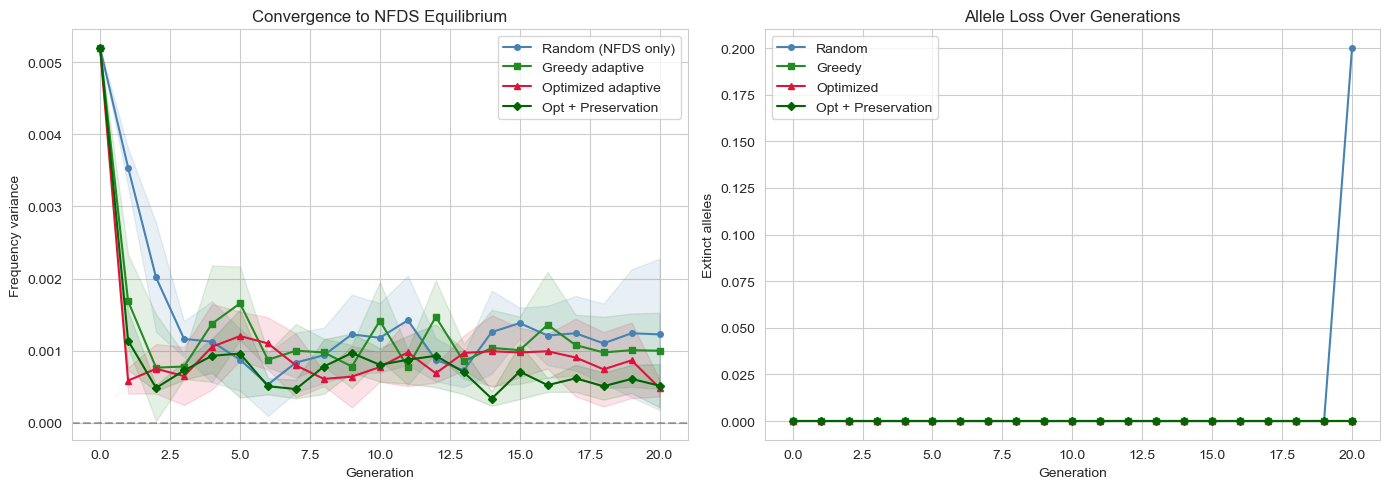


Final variance by strategy:
  Random (NFDS only):    0.001227
  Greedy adaptive:       0.001000
  Optimized adaptive:    0.000484
  Opt + Preservation:    0.000516

Final extinct alleles:
  Random: 0.2, Greedy: 0.0, Optimized: 0.0, Preserved: 0.0


In [7]:
generations = np.arange(n_generations + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for mean, std, label, color, marker in [
    (random_mean, random_std, "Random (NFDS only)", "steelblue", "o"),
    (greedy_mean, greedy_std, "Greedy adaptive", "forestgreen", "s"),
    (optimal_mean, optimal_std, "Optimized adaptive", "crimson", "^"),
    (preserved_mean, preserved_std, "Opt + Preservation", "darkgreen", "D"),
]:
    ax1.plot(generations, mean, f"-{marker}", color=color, markersize=4, label=label)
    ax1.fill_between(generations, mean - std, mean + std, alpha=0.12, color=color)

ax1.axhline(y=0, color="black", linestyle="--", alpha=0.3)
ax1.set_xlabel("Generation")
ax1.set_ylabel("Frequency variance")
ax1.set_title("Convergence to NFDS Equilibrium")
ax1.legend()

# Allele loss comparison
for ext, label, color, marker in [
    (random_ext, "Random", "steelblue", "o"),
    (greedy_ext, "Greedy", "forestgreen", "s"),
    (optimal_ext, "Optimized", "crimson", "^"),
    (preserved_ext, "Opt + Preservation", "darkgreen", "D"),
]:
    ax2.plot(generations, ext, f"-{marker}", color=color, markersize=4, label=label)

ax2.set_xlabel("Generation")
ax2.set_ylabel("Extinct alleles")
ax2.set_title("Allele Loss Over Generations")
ax2.legend()

plt.tight_layout()
plt.show()

print("\nFinal variance by strategy:")
print(f"  Random (NFDS only):    {random_mean[-1]:.6f}")
print(f"  Greedy adaptive:       {greedy_mean[-1]:.6f}")
print(f"  Optimized adaptive:    {optimal_mean[-1]:.6f}")
print(f"  Opt + Preservation:    {preserved_mean[-1]:.6f}")
print(f"\nFinal extinct alleles:")
print(f"  Random: {random_ext[-1]:.1f}, Greedy: {greedy_ext[-1]:.1f}, "
      f"Optimized: {optimal_ext[-1]:.1f}, Preserved: {preserved_ext[-1]:.1f}")

## Top Recommended Crosses

The optimal weight vector tells us which specific crosses to prioritize.

In [8]:
# Build a table of top crosses ranked by optimal weight.
# For a practitioner, this table answers: "Which specific crosses should I
# prioritize to most efficiently equalize allele frequencies?"
# Columns:
#   Maternal / Pollen: the two parent genotypes (directed cross)
#   Compatibility: fraction of pollen gametes accepted by SI (higher = easier cross)
#   Optimal weight: proportion of crossing effort to allocate (from scipy optimization)
#   Greedy weight: proportion from the heuristic rare-allele-boosting strategy
cross_data = []
for k in range(n_crosses):
    i, j, compat = compatible_crosses[k]
    cross_data.append({
        "Maternal": str(population[i]),
        "Pollen": str(population[j]),
        "Compatibility": compat,
        "Optimal weight": optimal_weights[k],
        "Greedy weight": greedy_weights[k],
    })

df_crosses = pd.DataFrame(cross_data)
df_top = df_crosses.nlargest(15, "Optimal weight")

print("Top 15 crosses by optimal weight:")
print(df_top.to_string(index=False, float_format="{:.4f}".format))

Top 15 crosses by optimal weight:
    Maternal       Pollen  Compatibility  Optimal weight  Greedy weight
(1, 2, 5, 6) (1, 2, 7, 8)         0.1667          0.0287         0.0175
(1, 3, 4, 5) (1, 3, 6, 7)         0.1667          0.0275         0.0125
(1, 2, 4, 4) (1, 2, 7, 8)         0.1667          0.0227         0.0187
(1, 2, 7, 8) (1, 2, 5, 6)         0.1667          0.0220         0.0062
(1, 2, 7, 8) (2, 2, 5, 6)         0.1667          0.0220         0.0062
(2, 3, 4, 8) (2, 3, 5, 6)         0.1667          0.0206         0.0062
(2, 3, 4, 8) (2, 2, 5, 6)         0.1667          0.0206         0.0062
(2, 3, 5, 6) (2, 4, 5, 8)         0.1667          0.0199         0.0100
(2, 3, 5, 6) (2, 3, 4, 8)         0.1667          0.0199         0.0100
(1, 3, 6, 7) (1, 3, 4, 5)         0.1667          0.0193         0.0037
(1, 3, 6, 7) (1, 1, 4, 5)         0.1667          0.0193         0.0037
(1, 1, 3, 5) (1, 3, 6, 7)         0.1667          0.0193         0.0125
(1, 2, 3, 3) (1, 2, 7, 8)     

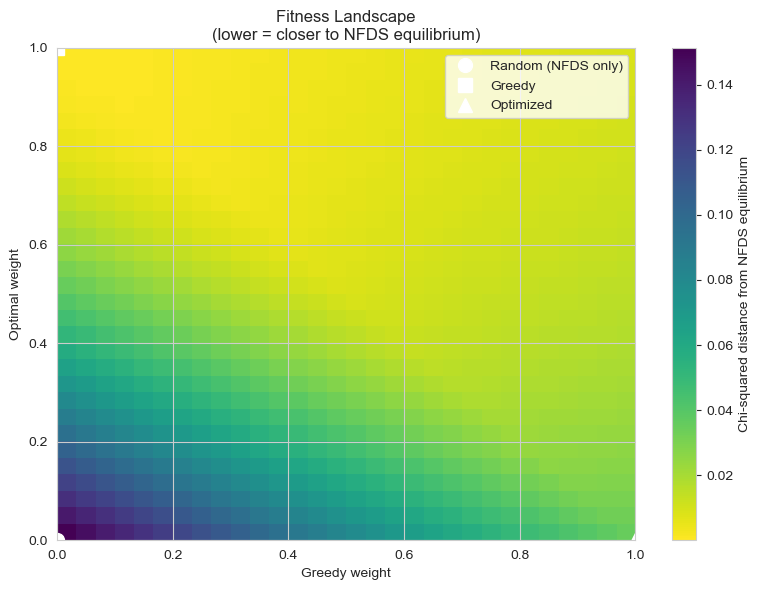

In [9]:
# ---------------------------------------------------------------------------
# Fitness landscape visualization (2D projection)
# ---------------------------------------------------------------------------
# The full weight space has n_crosses dimensions — far too many to visualize.
# We project onto 2 axes by mixing three known strategies:
#   w = alpha * optimal + beta * greedy + (1-alpha-beta) * uniform
# The x-axis varies the greedy mix, y-axis varies the optimal mix.
# Color shows chi-squared distance: darker = closer to NFDS equilibrium.
# This reveals the shape of the fitness landscape between the three strategies.

alpha_range = np.linspace(0, 1, 30)
beta_range = np.linspace(0, 1, 30)

uniform_weights = np.ones(n_crosses) / n_crosses

fitness_grid = np.zeros((len(alpha_range), len(beta_range)))

for ia, alpha in enumerate(alpha_range):
    for ib, beta in enumerate(beta_range):
        # Mix three strategies with non-negative remainder going to uniform
        remainder = max(0, 1 - alpha - beta)
        w = alpha * optimal_weights + beta * greedy_weights + remainder * uniform_weights
        w = w / w.sum()
        fitness_grid[ia, ib] = fitness_function(w)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(
    fitness_grid,
    extent=[0, 1, 0, 1],
    origin="lower",
    aspect="auto",
    cmap="viridis_r",
)
plt.colorbar(im, ax=ax, label="Chi-squared distance from NFDS equilibrium")

# Mark the three pure strategy locations on the landscape
ax.plot(0, 0, "wo", markersize=10, label="Random (NFDS only)")  # alpha=0, beta=0
ax.plot(0, 1, "ws", markersize=10, label="Greedy")               # alpha=0, beta=1
ax.plot(1, 0, "w^", markersize=10, label="Optimized")            # alpha=1, beta=0

ax.set_xlabel("Greedy weight")
ax.set_ylabel("Optimal weight")
ax.set_title("Fitness Landscape\n(lower = closer to NFDS equilibrium)")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()